# Explaratory Data Analysis

In this notebook, we create a lineplot and a heatmap to help us visualize our data (closing price and moving averages) and determine what features we should add/remove in the training of our models.

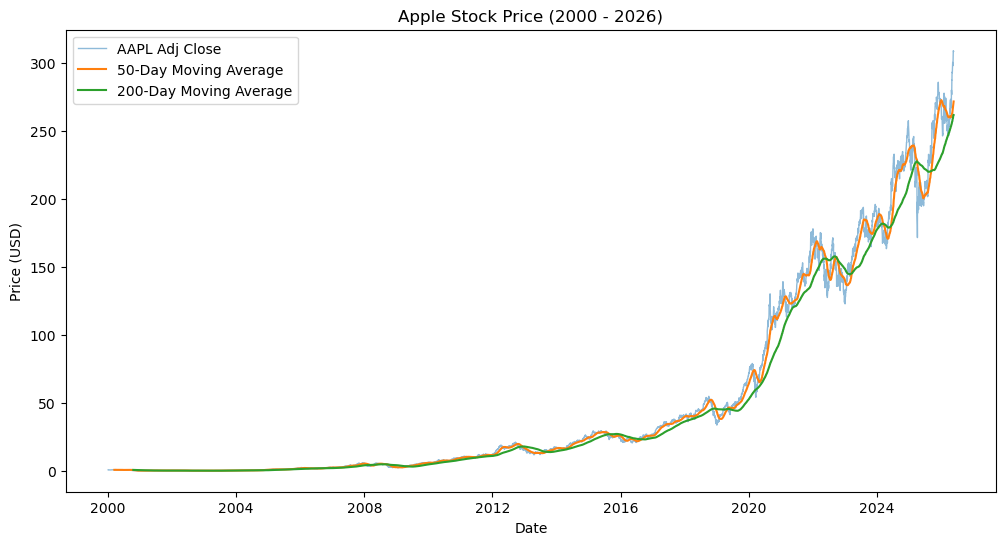

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('APPLE_daily_reformed.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['SMA_50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA_200'] = df['Adj Close'].rolling(window=200).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Adj Close'], label='AAPL Adj Close', alpha=0.5, linewidth=1)
plt.plot(df.index, df['SMA_50'], label='50-Day Moving Average', linewidth=1.5)
plt.plot(df.index, df['SMA_200'], label='200-Day Moving Average', linewidth=1.5)

plt.title('Apple Stock Price (2000 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

This lineplot represents the closing price for Apple stock from January 3, 2000 to May 26, 2026. In this plot, we show three lines: adjusted close for each day, 50 day simple moving average, and 200 day simple moving average. The adjusted close accounts for corporate actions such as stock splits and dividents. As such, using the adjusted closing price over closing price allows us to better understand the stock's true nature over time by providing a more accurate baseline for analysis across different periods. The moving average (50 days and 200 days) ensures that the impacts of random, short-term fluctuations on the stock price over a specified time frame are mitigated, allowing us to better visualize the trends and patterns in the data while minimizing the noise. We plan to incorporate the moving average instead of solely relying on the daily closing prices for the training of our models, both in the linear regression and random forest models.



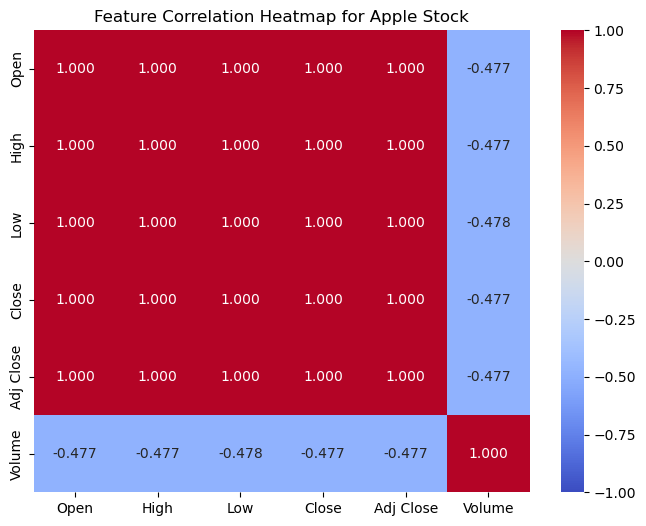

In [ ]:
import seaborn as sns

numerical_features = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

corr_matrix = numerical_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap for Apple Stock')
plt.show()

The correlation heatmap represents the relationship between the features in our data. Analyzing the heatmap reveals that the opening price, high, low, close, and adjusted close are all nearly perfectly correlated (as seen by the Pearson Coefficient of 1), while only trading volume demonstrated a weak linear correlation with the closing price. Due to the redundancy of several of these features, we plan to create several new features to feed into our model:

1. Daily Returns: The **daily returns** represent the percentage change in closing price from one day to the next, representing how fast the stock is moving in a set time frame. Using multiple timeframes (1, 2, 5, 10, and 20 days) allows the model to see if the stock is trending strongly over a month (20 days) or just fluctuating in the short term (1 day). Ultimately, it allows us to more easily compare how much a stock has fallen/risen over a certain period of time and provides more meanignful (standardized) data for our model to compare and understand.

2. Moving Averages (MA) & Ratios: The **moving average represents** the "trend" in our data, smoothing out the noise and helping the model better capture the underlying pattern/momentum by reducing the volatility that occurs in day-to-day trading. By doing this, it reduces the short-term spikes and fluctutations that can help prevent our models from overfitting . The **price vs moving average ratio** represents deviation and measures how far the closing price strays from the recent average, while the **moving average ratio (MA5 vs MA10)** compares long-term trends vs short-term trends by measuring whether short-term momenetum is gaining or losing against long-term trends. Using ratios (percentages) instead of raw data makes it easier to compare prices across different time periods, especially when those prices differ drastically over time.

3. Relative Strength Index (RSI): The **RSI** measures the speed and magntiude of recent price changes. It measure momentum of the stock that is independent of the absolute stock price (bounded between 0 and 100) and can help indicate whether a stock is overbought or oversold, helping our model better predict whether a stock is going to rise or fall based on how steady the price has moved.

4. Volatility & Volume Ratio: The **volatility** is the standard deviation of returns and represents how much the stock price is fluctuating. Having this distinction enables our model to better understand how the price will change in the near future by adding a measure of uncertainty and market instability, allowing it to adjust its predictions based on current conditions. The **volume ratio** compares today’s trading volume to the recent average, enabling our model to better understand price changes in the future by adding a measure of trading activity, which indicates how strongly price movements are supported by market participation. By incorporating market participation, it can help our model distinguish between meaningful price movements and random noise, allowing it to better predict whether a trend is likely to continue.

5. Percentages: The **high-low percentages** measures how much the stock price changed throughout the trading day scaled by the closing price,reflecting how stable or active the trading session was. It gives further context to the closing price, helping the model learn from how the price moved throughout the day and enabling it to differentiate between smooth/chaotic trading sessions that can signal different future outcomes. The **open-close percentages** measures the difference between opening and closing price scaled by the closing price, reflecting the stock's performance throughout the trading session. It serves as additional context to the closing pirce by telling the model whether there was an overall upward or downward trend throughout the day, helping it distinguish between days where the price steadily rose/fell vs days where trading activity was more volatile.

6. Lag Return: The **lag returns** provides historical context by measuring the percentage return from the previous days (1, 2, and 5 days). Ultimately, it represents how the stock has been moving in recent days, and provides details about whether the price has been trending upward, downward, or possibly reversing. By using these short-term patterns and whether the stock has been rising or falling over the past few days, it helps the model identify the stock's trend and momentum, ultimately improving its ability to predict the stock's behavior in the near future.

